# 201 — Re-evaluate baseline Pareto designs under known T scenarios

This notebook holds the **baseline `fish_dollars` Pareto designs fixed** and re-evaluates those same pumping designs under three transmissivity assumptions:

1. `T_minus_10pct` — transmissivity is 10% lower than the baseline value
2. `baseline_T` — transmissivity is the original baseline value
3. `T_plus_10pct` — transmissivity is 10% higher than the baseline value

The goal is to isolate the hydrologic effect of using a design that was optimized under one assumed transmissivity value when the true transmissivity may be different.

In plain language: **we are not re-optimizing here. We are asking how the same baseline pumping designs perform if T is wrong.**

---
## 1. Imports, user controls, and project paths

This section loads the packages and defines the main settings for the notebook.

The most important control is:

```python
RERUN_REEVALUATION = False
```

When this is `False`, the notebook will use the cached re-evaluation results if they already exist. When it is `True`, the notebook will rerun the PyCap fish-dollars forward model for every selected Pareto member and every T scenario.

In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Force Python/Jupyter to import the helper script from THIS notebook folder.
# -----------------------------------------------------------------------------
NOTEBOOK_DIR = Path.cwd().resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

sys.modules.pop("uncertainty_project_helpers", None)
importlib.invalidate_caches()

import uncertainty_project_helpers as up

# Confirm that the expected helper file is being used.
print("Imported helper from:", Path(up.__file__).resolve())
print("Helper version:", getattr(up, "HELPER_VERSION", "not reported"))

# Apply the shared plotting defaults. Edit up.PLOT_STYLE in the helper if you
# want project-wide figure changes, or override specific settings below.
up.apply_plot_style()

# =============================================================================
# User-editable settings
# =============================================================================

# Baseline MOU run whose Pareto-front designs will be re-evaluated.
# This is the original fish-dollars run; we are using its Pareto designs as the
# fixed management alternatives for this known-error experiment.
RUN_NAME = "fish_dollars_baseline_0.0_1.0_0.01"

# Use all final-generation feasible front-1 members by default.
# For a very quick smoke test, set this to a small integer like 5 or 10.
N_TEST_MEMBERS = None

# Cache switch:
#   False = load cached re-evaluation if it already exists
#   True  = rerun the PyCap re-evaluation and overwrite the cache
RERUN_REEVALUATION = True

# Historic/reference streamflow used for this project.
# Streamflow is calculated as: historic streamflow - depletion.
HISTORIC_STREAMFLOW_CFS = 8.6

# Depletion observation name written by the PyCap forward model.
DEPLETION_OBS_NAME = "lpr:total_combined:bdpl"

# Pumping metric to use on hydrologic plots.
# We use effective_total_pumping_cfs because the fish-dollars script turns off
# farms when pumping falls below the 70% cutoff, so effective pumping is the
# pumping actually passed through the forward model after that rule is applied.
PUMPING_COLUMN_FOR_HYDRO_PLOTS = "effective_total_pumping_cfs"

# T scenarios: label -> T multiplier relative to the baseline PyCap T.
# These labels are also used in plot legends and output files.
T_SCENARIOS = {
    "T_minus_10pct": 0.90,
    "baseline_T": 1.00,
    "T_plus_10pct": 1.10,
}

# =============================================================================
# Robust paths
# =============================================================================

# The notebook is intended to live in:
#   LPR_pycap_opt/notebooks/Uncertainty_Project/
# but the helper can find LPR_pycap_opt by walking upward from the current folder.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = up.find_lpr_pycap_opt_dir(NOTEBOOK_DIR)

# Standardized output/cache folders for this notebook.
dirs = up.make_project_dirs(NOTEBOOK_DIR, "201", "reevaluate_baseline_pareto_under_T_scenarios")
OUTPUT_DIR = dirs["output_dir"]
CACHE_DIR = dirs["cache_dir"]

# Cached model re-evaluation files. These allow you to rerun the notebook and
# remake plots/tables without rerunning all PyCap calculations every time.
CACHE_FILE = CACHE_DIR / "201_T_scenario_reevaluation_long.csv"
ERROR_CACHE_FILE = CACHE_DIR / "201_T_scenario_reevaluation_errors.csv"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_FILE:", CACHE_FILE)
print("RERUN_REEVALUATION:", RERUN_REEVALUATION)

Imported helper from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/uncertainty_project_helpers.py
Helper version: 2026-05-19_202_203_normal_distribution_plot_fix
NOTEBOOK_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios
CACHE_FILE: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/cached_reevaluations/201_T_scenario_reevaluation_long.csv
RERUN_REEVALUATION: True


---
## 2. Load the source model context and baseline Pareto designs

This section loads the original fish-dollars forward-model context and the baseline Pareto-front designs.

The important idea is that the original fish-dollars script remains the **source of truth** for re-evaluation. We do not manually recreate the PyCap calculation from scratch in the notebook. Instead, the helper script imports the original forward model logic, changes only T, and reruns each pumping design.

In [2]:
# Load the original fish-dollars forward-model context.
# This includes the copied forward script, the baseline YAML/project dictionary,
# the fish curve, the agricultural receipt table, and the baseline T value.
context = up.load_fish_dollars_context(RUN_NAME, PROJECT_DIR)

# Read the PEST++ MOU Pareto archive and select the final-generation feasible
# front-1 members. These are the baseline designs we will hold fixed.
pareto_archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
pareto_final = up.select_final_feasible_front1(
    pareto_archive,
    n_test_members=N_TEST_MEMBERS,
)

# Load all decision-variable population files. The decision variables are the
# well pumping rates for each Pareto member.
dv_df = up.load_decision_variable_population(context.run_dir)
q_cols = up.get_q_columns(dv_df)

# Make sure every selected Pareto member has a corresponding pumping design.
missing_members = sorted(set(pareto_final["member"]) - set(dv_df.index.astype(str)))

print("Using source-of-truth script:")
print(" ", context.script_path)
print("Final feasible front-1 members selected:", len(pareto_final))
print("Baseline T:", context.base_T)
print("Number of pumping-rate columns:", len(q_cols))
print("Missing final members in dv_df:", len(missing_members))

if missing_members:
    raise KeyError(f"Missing Pareto members in dv_pop files. First few: {missing_members[:10]}")

# Display the T scenarios in actual model units so it is clear what values will
# be passed into the PyCap project dictionary.
T_scenario_table = pd.DataFrame({
    "scenario": list(T_SCENARIOS.keys()),
    "T_factor": list(T_SCENARIOS.values()),
    "T_value": [context.base_T * f for f in T_SCENARIOS.values()],
})
display(T_scenario_table)

Using source-of-truth script:
  /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_fish_dollars_baseline_0.0_1.0_0.01/run_pycap_standalone_opt_mou_fish_dollars.py
Final feasible front-1 members selected: 174
Baseline T: 1700.0
Number of pumping-rate columns: 327
Missing final members in dv_df: 0


,scenario,T_factor,T_value
0,T_minus_10pct,0.9,1530.0
1,baseline_T,1.0,1700.0
2,T_plus_10pct,1.1,1870.0


---
## 3. Re-evaluate the baseline designs under alternate T values

This section is the computational core of the notebook.

For every selected baseline Pareto member, the notebook:

1. extracts the member's pumping design,
2. applies the fish-dollars pumping cutoff rule through the original forward model,
3. evaluates that same design under each T scenario,
4. calculates depletion and streamflow, and
5. saves the long-format results to a cache file.

If the cache already exists and `RERUN_REEVALUATION = False`, this section loads the saved results instead of rerunning PyCap.

The summary table is now created with `up.summarize_known_T_scenarios()` so the saved `201_T_scenario_summary.csv` has the column names expected by Notebook `203`.


In [3]:
# =============================================================================
# Re-evaluate under T scenarios, or load cached results
# =============================================================================

if CACHE_FILE.exists() and not RERUN_REEVALUATION:
    # Fast path: use previously saved re-evaluation results.
    # This avoids rerunning the PyCap/fish-dollars forward model if the cache is
    # already available.
    print("Loading cached T-scenario re-evaluation:", CACHE_FILE)
    results_long = pd.read_csv(CACHE_FILE)
    error_df = pd.read_csv(ERROR_CACHE_FILE) if ERROR_CACHE_FILE.exists() else pd.DataFrame()
else:
    # Slow path: rerun the PyCap/fish-dollars forward model for each design and
    # each T scenario. This is the heavy-lifting step.
    results_long, error_df = up.reevaluate_designs(
        pareto_final=pareto_final,
        dv_df=dv_df,
        q_cols=q_cols,
        context=context,
        scenarios=T_SCENARIOS,
        historic_streamflow_cfs=HISTORIC_STREAMFLOW_CFS,
        depletion_obs_name=DEPLETION_OBS_NAME,
    )

    # Cache the raw long-format re-evaluation results so future notebook runs can
    # focus on plotting/analysis without repeating all forward-model calls.
    results_long.to_csv(CACHE_FILE, index=False)
    if not error_df.empty:
        error_df.to_csv(ERROR_CACHE_FILE, index=False)
    print("Saved cache:", CACHE_FILE)

# -----------------------------------------------------------------------------
# Add baseline-relative metrics.
# -----------------------------------------------------------------------------
# This step is essential. Notebook 203 expects the summary file from this notebook
# to include columns like mean_streamflow_change_from_baseline_cfs and
# mean_streamflow_shortfall_below_baseline_cfs. Those columns only exist after we
# compare each T scenario against the same member evaluated at baseline T.
results_long = up.add_known_T_error_metrics(
    results_long,
    baseline_label="baseline_T",
)

# Wide format is more convenient for scenario overlay plots because each scenario
# becomes a set of columns on the same member row.
results_wide = up.make_wide_by_scenario(results_long)

# Scenario summary gives quick diagnostics by T assumption. Use the helper version
# rather than a hand-written groupby so the saved CSV always has the column names
# that Notebook 203 expects.
scenario_summary = up.summarize_known_T_scenarios(results_long)

# Safety check: fail early with a clear message if the summary file would not be
# compatible with Notebook 203.
required_203_columns = [
    "mean_streamflow_change_from_baseline_cfs",
    "mean_streamflow_shortfall_below_baseline_cfs",
    "max_streamflow_shortfall_below_baseline_cfs",
]
missing_203_columns = [c for c in required_203_columns if c not in scenario_summary.columns]
if missing_203_columns:
    raise KeyError(
        "201_T_scenario_summary.csv would be missing columns needed by Notebook 203: "
        f"{missing_203_columns}"
    )

display(scenario_summary)

if not error_df.empty:
    print("Errors were encountered during re-evaluation:")
    display(error_df.head())



Scenario: T_minus_10pct | T factor: 0.9 | T value: 1530
  Re-evaluating 1 of 522: scenario=T_minus_10pct, member=gen=47_member=5907_pso
  Re-evaluating 50 of 522: scenario=T_minus_10pct, member=gen=41_member=5214_pso
  Re-evaluating 100 of 522: scenario=T_minus_10pct, member=gen=47_member=5999_pso
  Re-evaluating 150 of 522: scenario=T_minus_10pct, member=gen=34_member=4241_pso

Scenario: baseline_T | T factor: 1 | T value: 1700
  Re-evaluating 200 of 522: scenario=baseline_T, member=gen=38_member=4778_pso
  Re-evaluating 250 of 522: scenario=baseline_T, member=gen=24_member=2976_pso
  Re-evaluating 300 of 522: scenario=baseline_T, member=gen=33_member=4206_pso

Scenario: T_plus_10pct | T factor: 1.1 | T value: 1870
  Re-evaluating 350 of 522: scenario=T_plus_10pct, member=56
  Re-evaluating 400 of 522: scenario=T_plus_10pct, member=gen=45_member=5714_pso
  Re-evaluating 450 of 522: scenario=T_plus_10pct, member=gen=46_member=5794_pso
  Re-evaluating 500 of 522: scenario=T_plus_10pct,

,scenario,T_factor,T_value,n_members,mean_effective_total_pumping_cfs,mean_depletion_cfs,mean_streamflow_cfs,mean_streamflow_change_from_baseline_cfs,mean_absolute_streamflow_error_cfs,max_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,T_minus_10pct,0.9,1530.0,174,107.288405,2.544795,6.055205,0.160708,0.160708,0.254155,0.000000,0.000000
1,baseline_T,1.0,1700.0,174,107.288405,2.705503,5.894497,0.000000,0.000000,0.000000,0.000000,0.000000
2,T_plus_10pct,1.1,1870.0,174,107.288405,2.856156,5.743844,-0.150653,0.150653,0.235821,0.150653,0.235821


---
## 4. Create the individual known-T-error plots

This section preserves the individual figures. These are useful when you want a single clean figure for a report or presentation.

The four individual figures are:

1. pumping vs streamflow for all T scenarios,
2. pumping vs depletion for all T scenarios,
3. streamflow change from baseline T,
4. absolute streamflow error from baseline T.

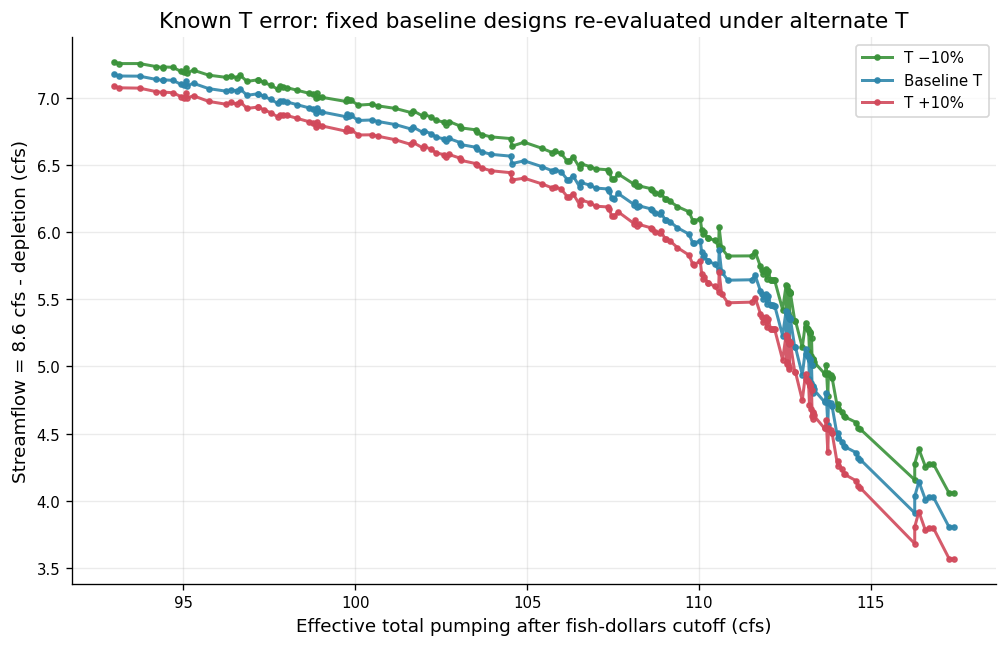

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_pumping_vs_streamflow_T_scenarios.png


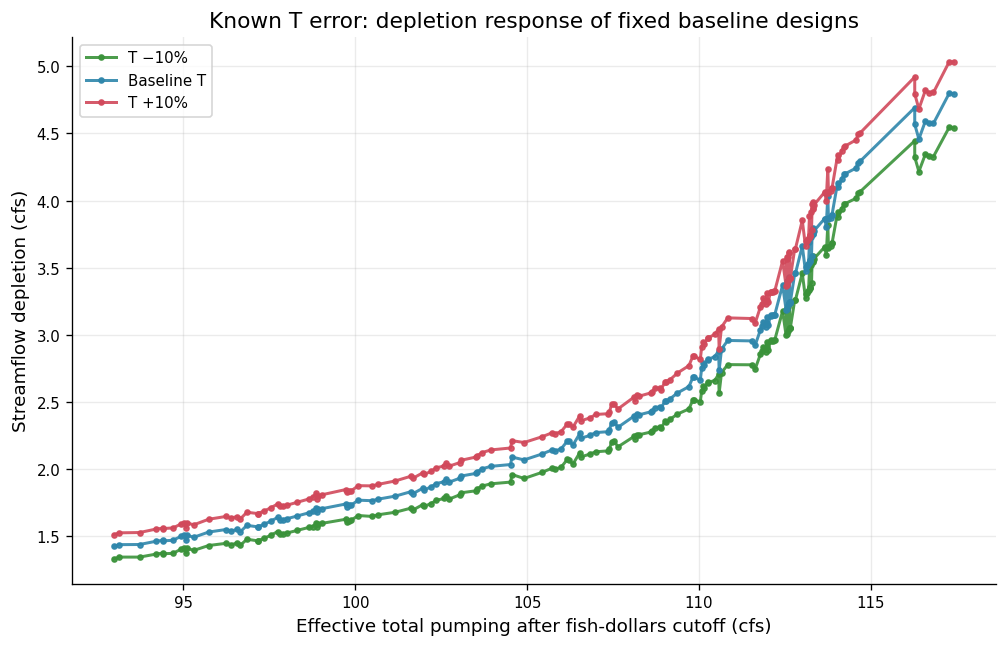

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_pumping_vs_depletion_T_scenarios.png


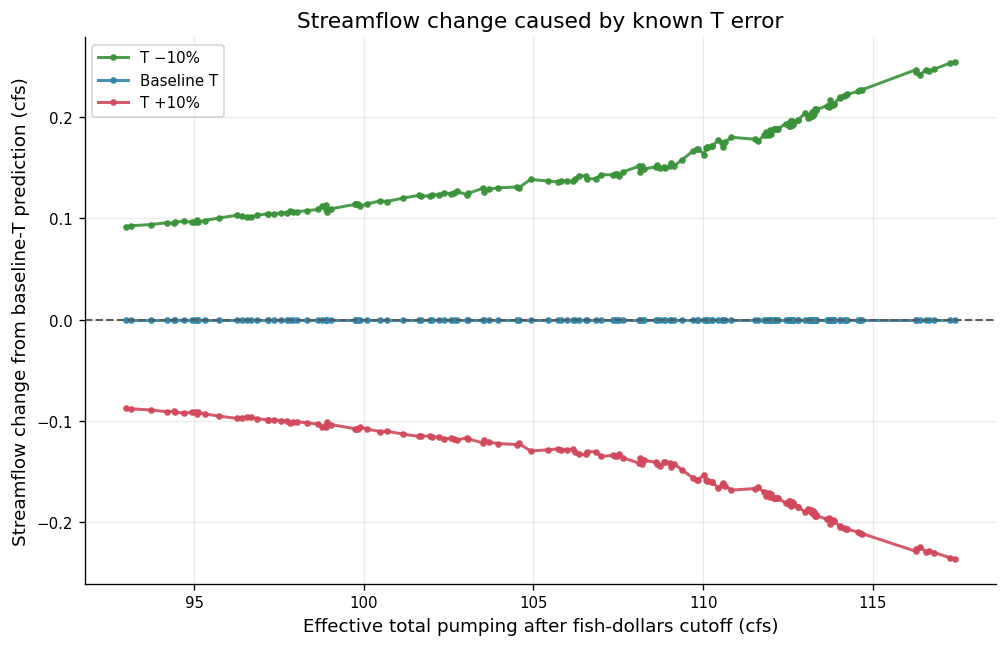

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_streamflow_change_from_baseline_vs_pumping.png


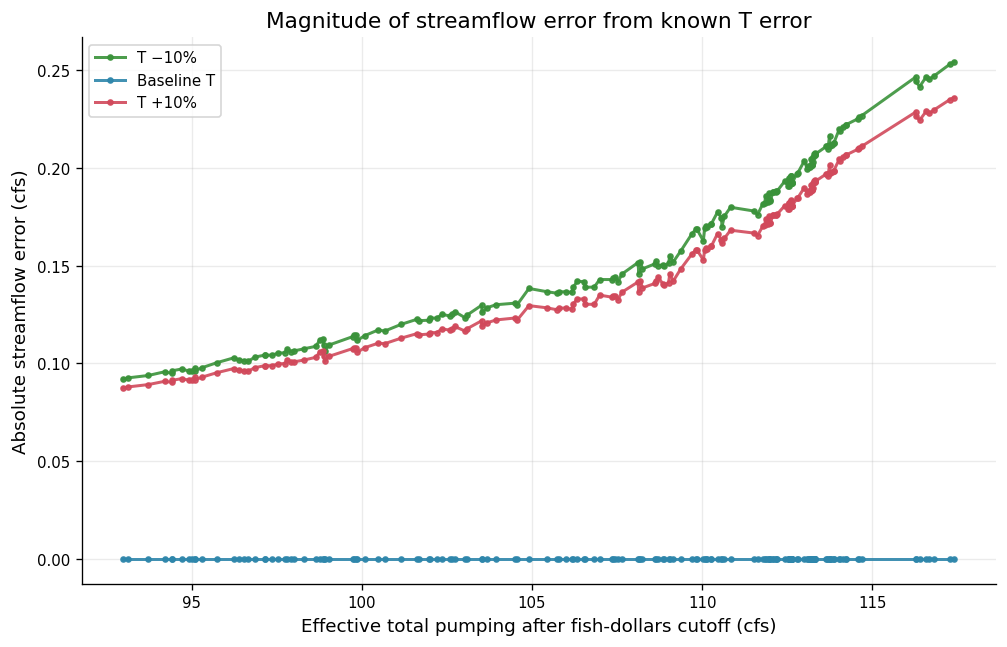

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_absolute_streamflow_error_vs_pumping.png


In [4]:
# =============================================================================
# Individual plots
# =============================================================================

# Plot 1: fixed baseline designs shown as pumping vs streamflow under each T.
up.plot_scenario_lines(
    results_wide,
    xcol=PUMPING_COLUMN_FOR_HYDRO_PLOTS,
    ycols_by_scenario={
        "T_minus_10pct": "streamflow_cfs__T_minus_10pct",
        "baseline_T": "streamflow_cfs__baseline_T",
        "T_plus_10pct": "streamflow_cfs__T_plus_10pct",
    },
    xlabel="Effective total pumping after fish-dollars cutoff (cfs)",
    ylabel="Streamflow = 8.6 cfs - depletion (cfs)",
    title="Known T error: fixed baseline designs re-evaluated under alternate T",
    outfile=OUTPUT_DIR / "201_pumping_vs_streamflow_T_scenarios.png",
)

# Plot 2: same x-axis, but showing depletion directly instead of streamflow.
up.plot_scenario_lines(
    results_wide,
    xcol=PUMPING_COLUMN_FOR_HYDRO_PLOTS,
    ycols_by_scenario={
        "T_minus_10pct": "depletion_cfs__T_minus_10pct",
        "baseline_T": "depletion_cfs__baseline_T",
        "T_plus_10pct": "depletion_cfs__T_plus_10pct",
    },
    xlabel="Effective total pumping after fish-dollars cutoff (cfs)",
    ylabel="Streamflow depletion (cfs)",
    title="Known T error: depletion response of fixed baseline designs",
    outfile=OUTPUT_DIR / "201_pumping_vs_depletion_T_scenarios.png",
)

# Long format is convenient for the next two error/change plots.
plot_df = up.sort_for_plot(results_long, PUMPING_COLUMN_FOR_HYDRO_PLOTS)

# Plot 3: signed streamflow change relative to the baseline-T prediction.
# Negative values mean streamflow is lower than expected from baseline T.
fig, ax = plt.subplots()
for scen, group in plot_df.groupby("scenario", sort=False):
    ax.plot(
        group[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
        group["streamflow_change_from_baseline_cfs"],
        marker="o",
        markersize=3,
        label=up.SCENARIO_LABELS.get(scen, scen),
        color=up.SCENARIO_COLORS.get(scen),
        alpha=0.9,
    )
ax.axhline(0, linestyle="--", color="0.35", linewidth=1.2)
ax.set_xlabel("Effective total pumping after fish-dollars cutoff (cfs)")
ax.set_ylabel("Streamflow change from baseline-T prediction (cfs)")
ax.set_title("Streamflow change caused by known T error")
ax.legend()
up.save_figure(fig, OUTPUT_DIR / "201_streamflow_change_from_baseline_vs_pumping.png")

# Plot 4: absolute magnitude of the streamflow error from using baseline T.
fig, ax = plt.subplots()
for scen, group in plot_df.groupby("scenario", sort=False):
    ax.plot(
        group[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
        group["absolute_streamflow_error_cfs"],
        marker="o",
        markersize=3,
        label=up.SCENARIO_LABELS.get(scen, scen),
        color=up.SCENARIO_COLORS.get(scen),
        alpha=0.9,
    )
ax.set_xlabel("Effective total pumping after fish-dollars cutoff (cfs)")
ax.set_ylabel("Absolute streamflow error (cfs)")
ax.set_title("Magnitude of streamflow error from known T error")
ax.legend()
up.save_figure(fig, OUTPUT_DIR / "201_absolute_streamflow_error_vs_pumping.png")

---
## 5. Create a combined 2x2 figure

This section adds a single summary figure containing the same four plots from Section 4.

The individual figures are still saved above. This combined figure is useful for quickly reviewing the known-T-error story in one place.

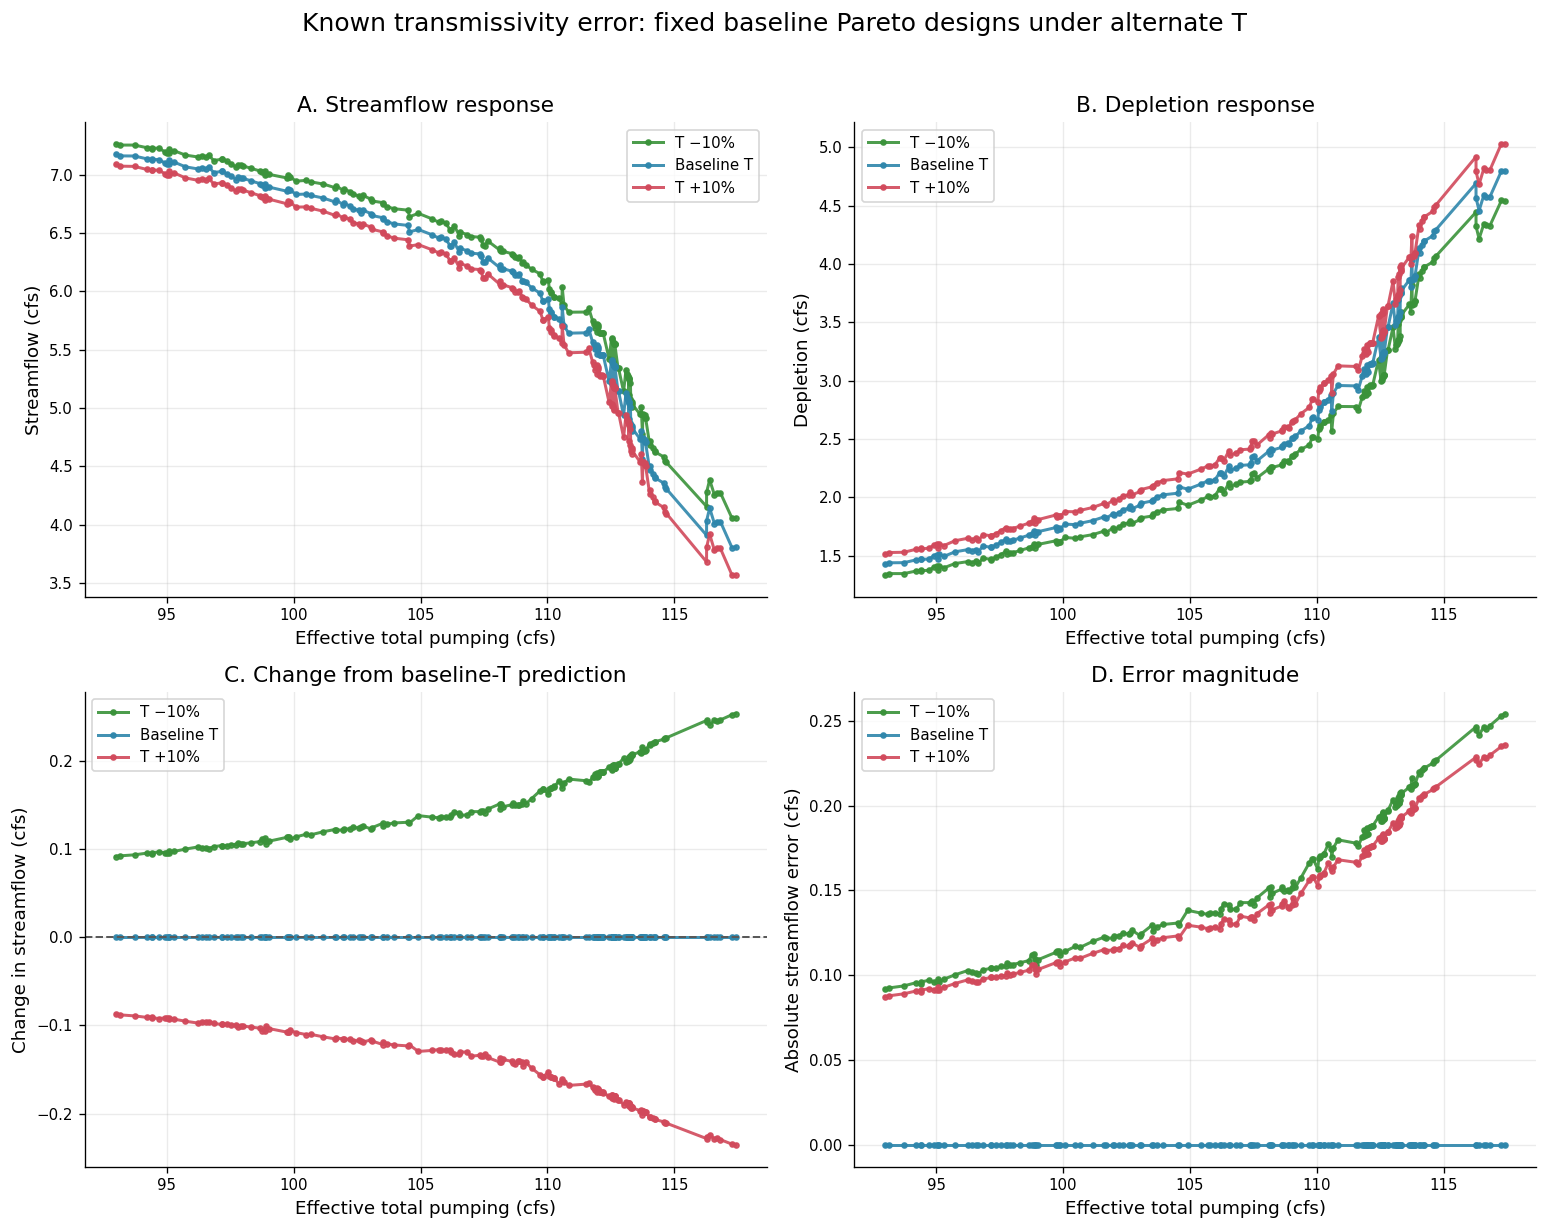

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_known_T_error_summary_2x2.png


In [5]:
# =============================================================================
# Combined 2x2 summary plot
# =============================================================================

# Helper dictionaries used in the two scenario-front panels.
streamflow_cols = {
    "T_minus_10pct": "streamflow_cfs__T_minus_10pct",
    "baseline_T": "streamflow_cfs__baseline_T",
    "T_plus_10pct": "streamflow_cfs__T_plus_10pct",
}

depletion_cols = {
    "T_minus_10pct": "depletion_cfs__T_minus_10pct",
    "baseline_T": "depletion_cfs__baseline_T",
    "T_plus_10pct": "depletion_cfs__T_plus_10pct",
}

# Use a larger figure because this is a multi-panel summary graphic.
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

# -----------------------------------------------------------------------------
# Panel A: pumping vs streamflow under each T assumption
# -----------------------------------------------------------------------------
ax = axes[0]
wide_plot_df = up.sort_for_plot(results_wide, PUMPING_COLUMN_FOR_HYDRO_PLOTS)
for scen, ycol in streamflow_cols.items():
    ax.plot(
        wide_plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
        wide_plot_df[ycol],
        marker="o",
        markersize=3,
        color=up.SCENARIO_COLORS.get(scen),
        label=up.SCENARIO_LABELS.get(scen, scen),
        alpha=0.9,
    )
ax.set_xlabel("Effective total pumping (cfs)")
ax.set_ylabel("Streamflow (cfs)")
ax.set_title("A. Streamflow response")
ax.legend()

# -----------------------------------------------------------------------------
# Panel B: pumping vs depletion under each T assumption
# -----------------------------------------------------------------------------
ax = axes[1]
for scen, ycol in depletion_cols.items():
    ax.plot(
        wide_plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
        wide_plot_df[ycol],
        marker="o",
        markersize=3,
        color=up.SCENARIO_COLORS.get(scen),
        label=up.SCENARIO_LABELS.get(scen, scen),
        alpha=0.9,
    )
ax.set_xlabel("Effective total pumping (cfs)")
ax.set_ylabel("Depletion (cfs)")
ax.set_title("B. Depletion response")
ax.legend()

# -----------------------------------------------------------------------------
# Panel C: signed streamflow change from the baseline-T prediction
# -----------------------------------------------------------------------------
ax = axes[2]
for scen, group in plot_df.groupby("scenario", sort=False):
    ax.plot(
        group[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
        group["streamflow_change_from_baseline_cfs"],
        marker="o",
        markersize=3,
        color=up.SCENARIO_COLORS.get(scen),
        label=up.SCENARIO_LABELS.get(scen, scen),
        alpha=0.9,
    )
ax.axhline(0, linestyle="--", color="0.35", linewidth=1.2)
ax.set_xlabel("Effective total pumping (cfs)")
ax.set_ylabel("Change in streamflow (cfs)")
ax.set_title("C. Change from baseline-T prediction")
ax.legend()

# -----------------------------------------------------------------------------
# Panel D: absolute streamflow error from using baseline T
# -----------------------------------------------------------------------------
ax = axes[3]
for scen, group in plot_df.groupby("scenario", sort=False):
    ax.plot(
        group[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
        group["absolute_streamflow_error_cfs"],
        marker="o",
        markersize=3,
        color=up.SCENARIO_COLORS.get(scen),
        label=up.SCENARIO_LABELS.get(scen, scen),
        alpha=0.9,
    )
ax.set_xlabel("Effective total pumping (cfs)")
ax.set_ylabel("Absolute streamflow error (cfs)")
ax.set_title("D. Error magnitude")
ax.legend()

fig.suptitle(
    "Known transmissivity error: fixed baseline Pareto designs under alternate T",
    fontsize=up.PLOT_STYLE.get("axes.titlesize", 13) + 2,
    y=1.02,
)

up.save_figure(fig, OUTPUT_DIR / "201_known_T_error_summary_2x2.png")

---
## 6. Save final outputs

This section writes the main result tables to the notebook output folder.

The cache files are for fast reruns. The output files are the clean products you can reference in your project writeup.

In [6]:
# =============================================================================
# Save final notebook outputs
# =============================================================================

# Long format: one row per member per T scenario.
results_long.to_csv(OUTPUT_DIR / "201_T_scenario_reevaluation_long.csv", index=False)

# Wide format: one row per member with separate columns for each T scenario.
results_wide.to_csv(OUTPUT_DIR / "201_T_scenario_reevaluation_wide.csv", index=False)

# Summary table: scenario-level statistics.
scenario_summary.to_csv(OUTPUT_DIR / "201_T_scenario_summary.csv", index=False)

# Error file is only written if any forward-model calls failed.
if not error_df.empty:
    error_df.to_csv(OUTPUT_DIR / "201_T_scenario_reevaluation_errors.csv", index=False)

print("Saved files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f.name)

Saved files:
 - 201_T_scenario_reevaluation_long.csv
 - 201_T_scenario_reevaluation_wide.csv
 - 201_T_scenario_summary.csv
 - 201_absolute_streamflow_error_vs_pumping.png
 - 201_known_T_error_summary_2x2.png
 - 201_pumping_vs_depletion_T_scenarios.png
 - 201_pumping_vs_streamflow_T_scenarios.png
 - 201_streamflow_change_from_baseline_vs_pumping.png
